In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [2]:
import pandas as pd

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"

# Read CSV directly from URL
df = pd.read_csv(URL)

print('Data downloaded and read into a dataframe!')
df.head()


Data downloaded and read into a dataframe!


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1/31/1980,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,2/29/1980,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,3/31/1980,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,4/30/1980,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,5/31/1980,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


#### TASK 1.1: Develop a Line chart using the functionality of pandas to show how automobile sales fluctuate from year to year

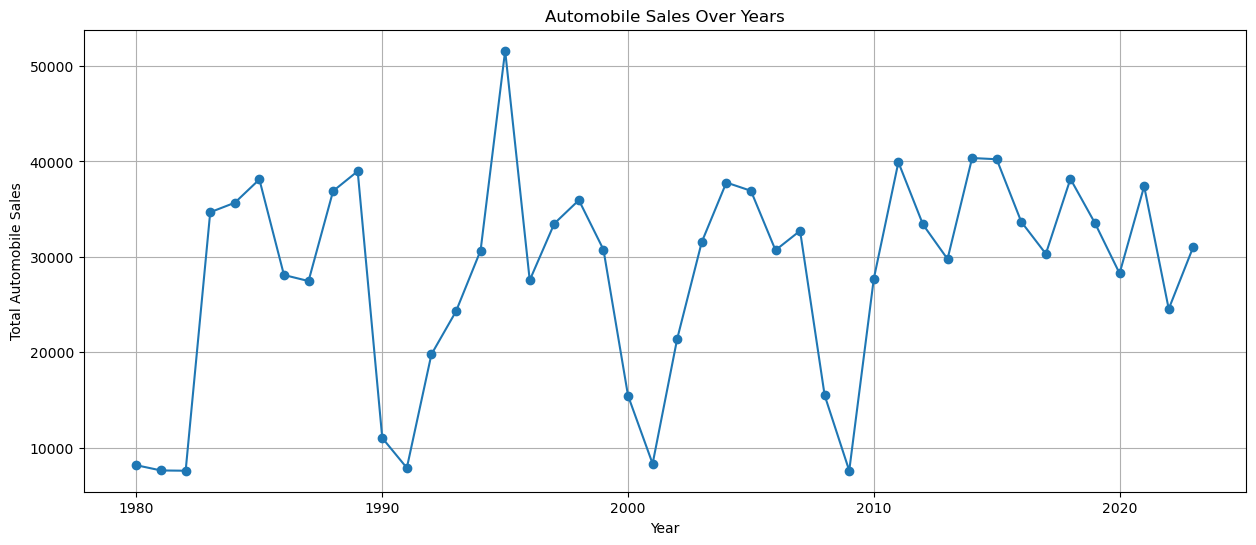

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'Date' is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Group by Year and calculate total or average sales per year
annual_sales = df.groupby('Year')['Automobile_Sales'].sum()  # or .mean() if you want average

# Plot using pandas
plt.figure(figsize=(15, 6))
annual_sales.plot(marker='o', linestyle='-')
plt.title('Automobile Sales Over Years')
plt.xlabel('Year')
plt.ylabel('Total Automobile Sales')
plt.grid(True)
plt.show()


#### TASK 1.2: Plot different lines for categories of vehicle type and analyse the trend to answer the question Is there a noticeable difference in sales trends between different vehicle types during recession periods?

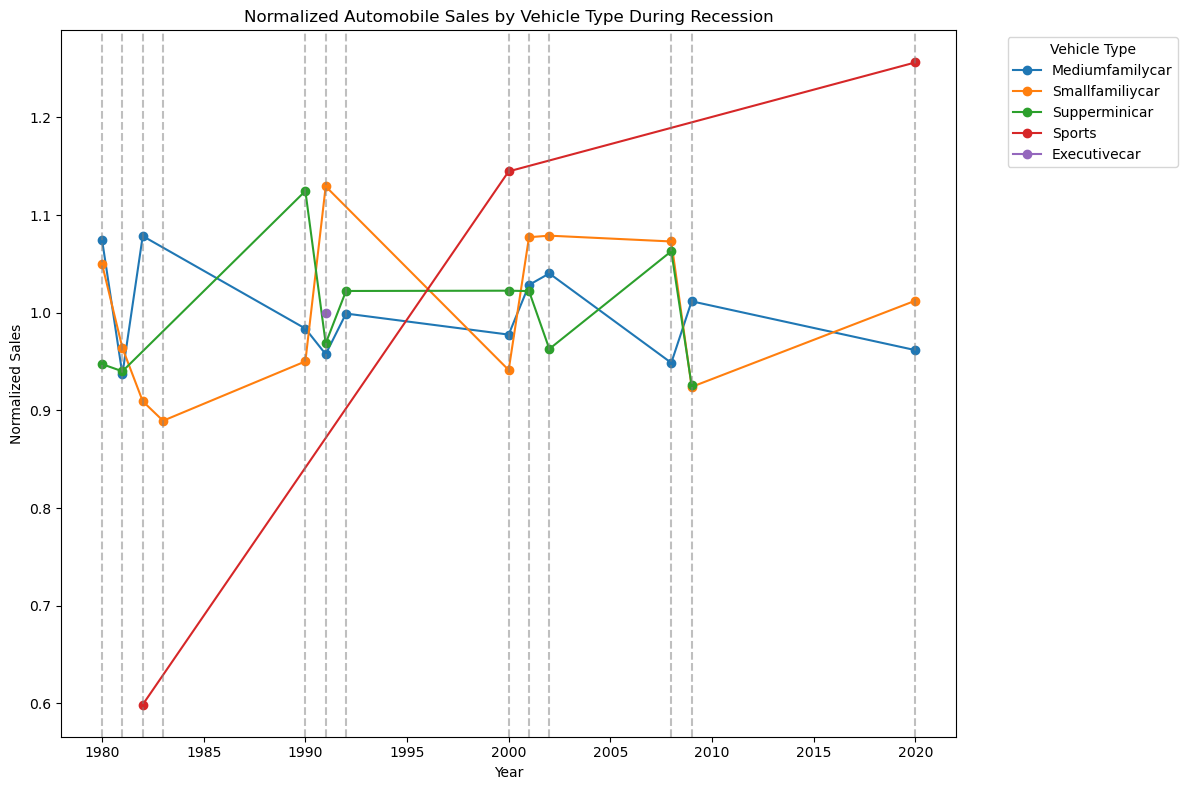

In [4]:
# Filter only recession periods
df_rec = df[df['Recession'] == 1]

# Calculate the average automobile sales by year and vehicle type during the recession
df_Mline = df_rec.groupby(['Year', 'Vehicle_Type'], as_index=False)['Automobile_Sales'].mean()

# Calculate the normalized sales by dividing by the average sales for each vehicle type
df_Mline['Normalized_Sales'] = df_Mline.groupby('Vehicle_Type')['Automobile_Sales'].transform(lambda x: x / x.mean())

# Set the 'Year' as the index
df_Mline.set_index('Year', inplace=True)

# Create the plot for each vehicle type
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
for vehicle_type in df_Mline['Vehicle_Type'].unique():
    data = df_Mline[df_Mline['Vehicle_Type'] == vehicle_type]
    plt.plot(data.index, data['Normalized_Sales'], label=vehicle_type, marker='o')

# Highlight recession years
recession_years = df_rec['Year'].unique()
for year in recession_years:
    plt.axvline(x=year, color='gray', linestyle='--', alpha=0.5)

# Add labels, legend, and title
plt.legend(title="Vehicle Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel("Normalized Sales")
plt.xlabel("Year")
plt.title("Normalized Automobile Sales by Vehicle Type During Recession")

# Show the plot
plt.tight_layout()
plt.show()


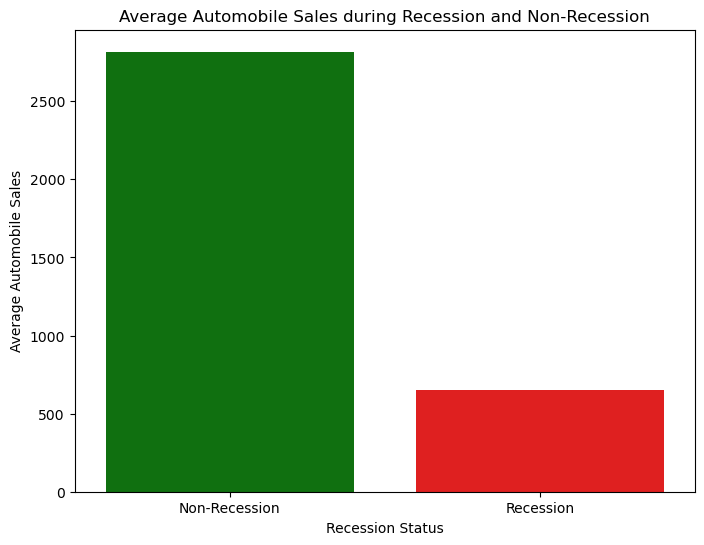

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate average automobile sales by Recession
new_df = df.groupby('Recession')['Automobile_Sales'].mean().reset_index()

# Create the bar chart using seaborn
plt.figure(figsize=(8, 6))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Recession', data=new_df, palette=['green','red'])

plt.xlabel('Recession Status')
plt.ylabel('Average Automobile Sales')
plt.title('Average Automobile Sales during Recession and Non-Recession')
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.legend([],[], frameon=False)  # optional: remove redundant legend
plt.show()


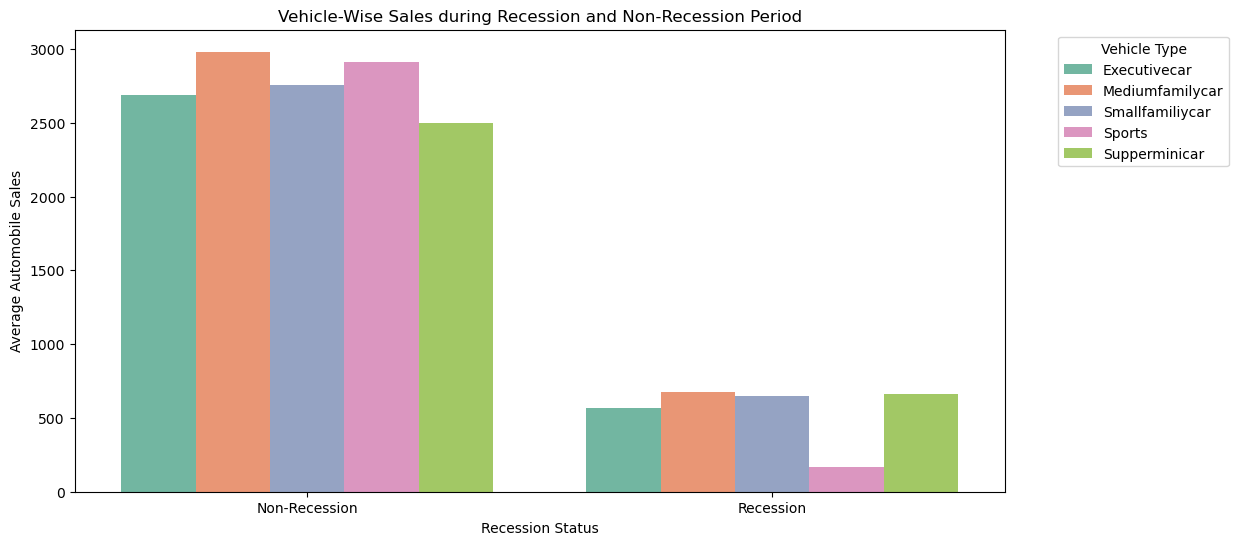

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Recession and Vehicle_Type, then calculate mean sales
grouped_df = df.groupby(['Recession', 'Vehicle_Type'])['Automobile_Sales'].mean().reset_index()

# Create the grouped bar chart using seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Vehicle_Type', data=grouped_df, palette='Set2')

# Customize x-ticks and labels
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.xlabel('Recession Status')
plt.ylabel('Average Automobile Sales')
plt.title('Vehicle-Wise Sales during Recession and Non-Recession Period')

plt.legend(title='Vehicle Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


From this plot, we can understand that there is a drastic decline in the overall sales of the automobiles during recession.
However, the most affected type of vehicle is executivecar and sports

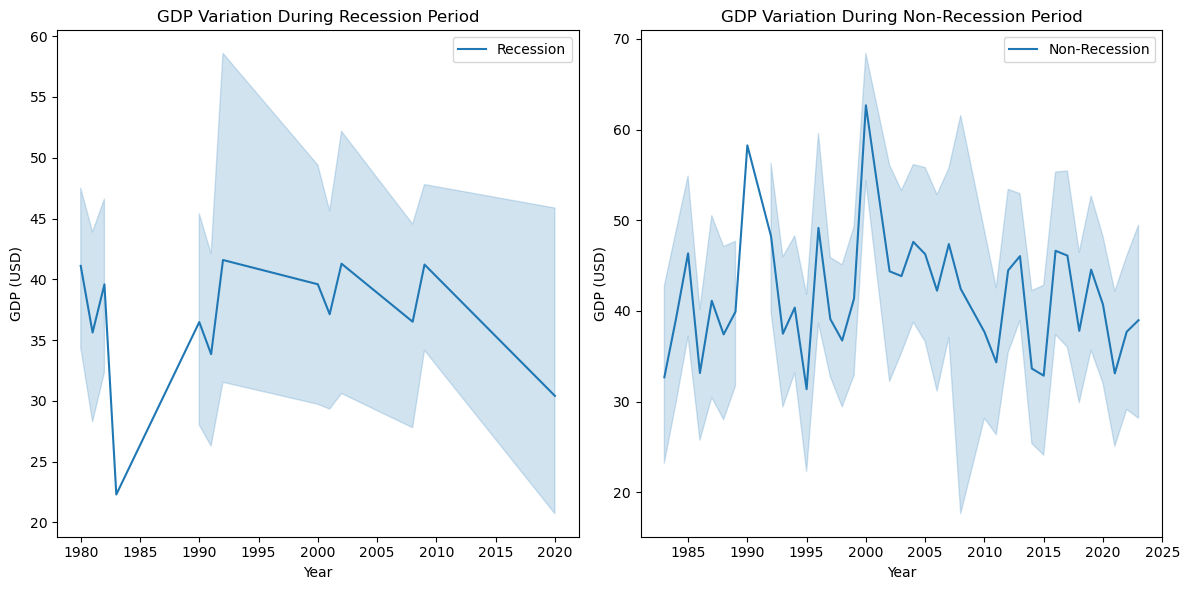

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create dataframes for recession and non-recession period
rec_data = df[df['Recession'] == 1]
non_rec_data = df[df['Recession'] == 0]

# Figure
fig = plt.figure(figsize=(12, 6))

# Create different axes for subplots
ax0 = fig.add_subplot(1, 2, 1)  # subplot 1 (1 row, 2 columns, first plot)
ax1 = fig.add_subplot(1, 2, 2)  # subplot 2 (1 row, 2 columns, second plot)

# Line plot for Recession period
sns.lineplot(x='Year', y='GDP', data=rec_data, label='Recession', ax=ax0)
ax0.set_xlabel('Year')
ax0.set_ylabel('GDP (USD)')
ax0.set_title('GDP Variation During Recession Period')

# Line plot for Non-Recession period
sns.lineplot(x='Year', y='GDP', data=non_rec_data, label='Non-Recession', ax=ax1)
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP (USD)')
ax1.set_title('GDP Variation During Non-Recession Period')

plt.tight_layout()
plt.show()


From this plot, it is evident that during recession, the GDP of the country was in a low range, might have afected the overall sales of the company

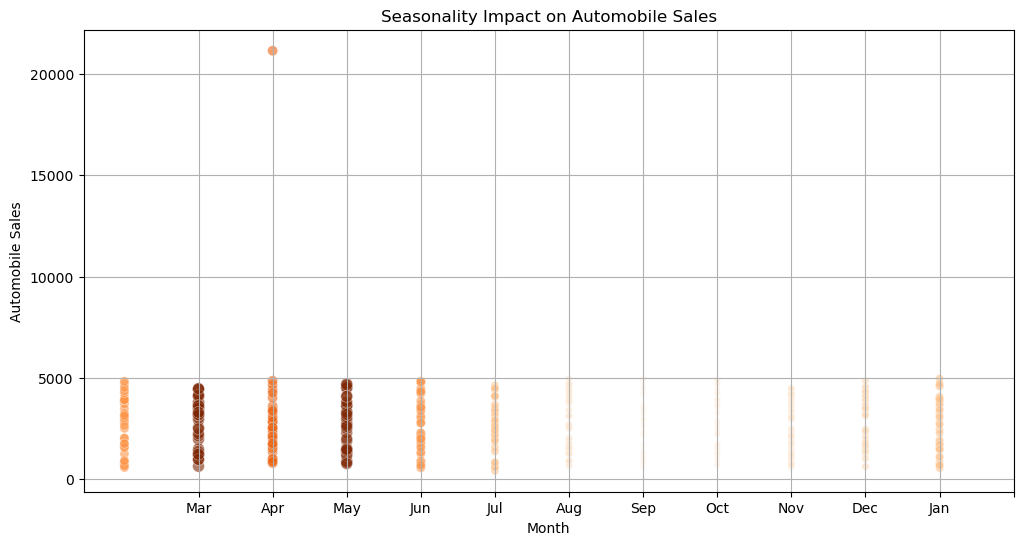

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter non-recession data
non_rec_data = df[df['Recession'] == 0]

# Bubble size based on Seasonality Weight
size = non_rec_data['Seasonality_Weight']

# Create bubble plot
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=non_rec_data,
    x='Month',
    y='Automobile_Sales',
    size=size,
    hue='Seasonality_Weight',   # optional: color based on seasonality
    palette='Oranges',
    legend=False,
    alpha=0.6
)

plt.xlabel('Month')
plt.ylabel('Automobile Sales')
plt.title('Seasonality Impact on Automobile Sales')
plt.xticks(range(1, 13))  # Show all months
plt.grid(True)
plt.show()


From this plot, it is evident that seasonality has not affected on the overall sales. However, there is a drastic raise in sales in the month of April

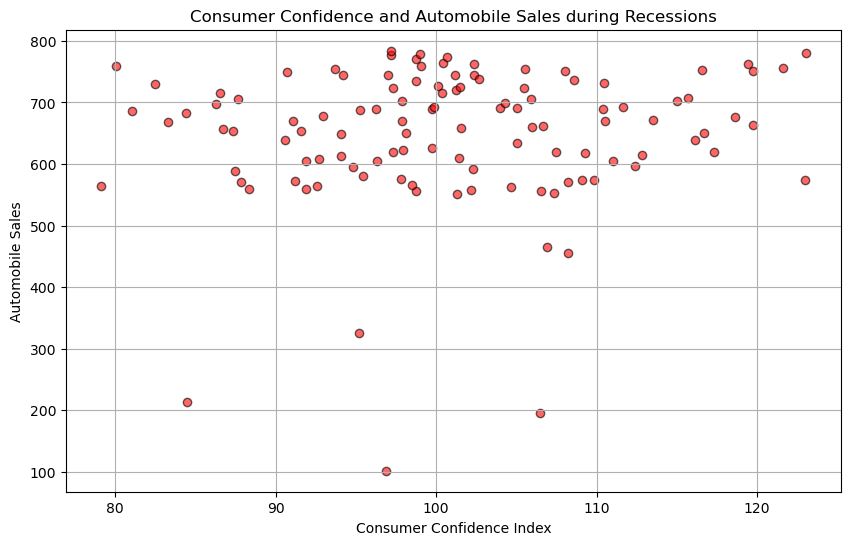

In [12]:
import matplotlib.pyplot as plt

# Filter data for recession periods
rec_data = df[df['Recession'] == 1]

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(rec_data['Consumer_Confidence'], rec_data['Automobile_Sales'], color='red', alpha=0.6, edgecolors='black')

# Labels and title
plt.xlabel('Consumer Confidence Index')
plt.ylabel('Automobile Sales')
plt.title('Consumer Confidence and Automobile Sales during Recessions')
plt.grid(True)
plt.show()


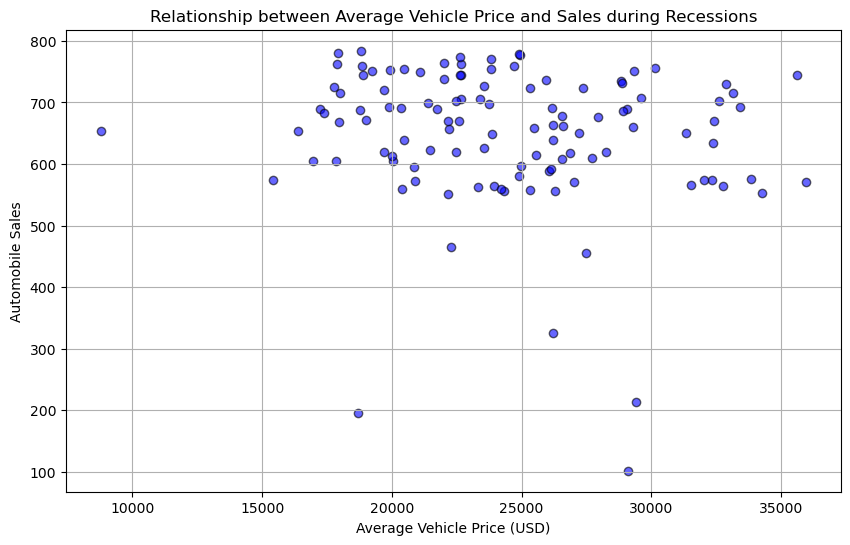

In [13]:
import matplotlib.pyplot as plt

# Filter data for recession periods
rec_data = df[df['Recession'] == 1]

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(rec_data['Price'], rec_data['Automobile_Sales'], color='blue', alpha=0.6, edgecolors='black')

# Labels and title
plt.xlabel('Average Vehicle Price (USD)')
plt.ylabel('Automobile Sales')
plt.title('Relationship between Average Vehicle Price and Sales during Recessions')
plt.grid(True)
plt.show()


There is not much relation!

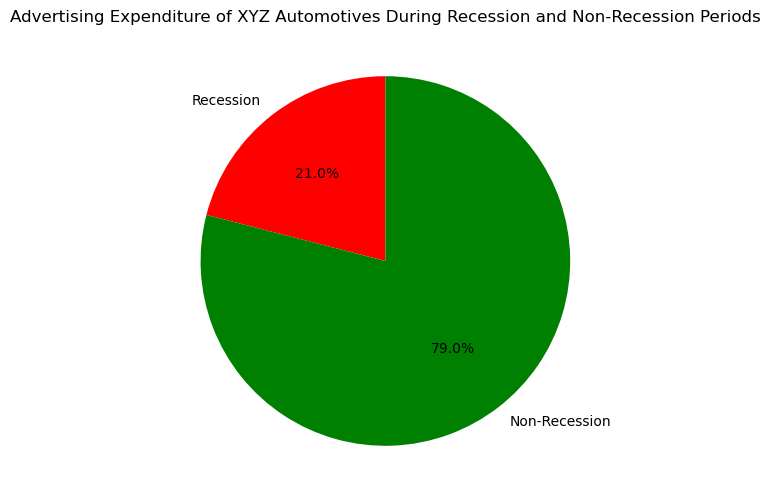

In [14]:
import matplotlib.pyplot as plt

# Filter the data 
Rdata = df[df['Recession'] == 1]
NRdata = df[df['Recession'] == 0]

# Calculate the total advertising expenditure for both periods
RAtotal = Rdata['Advertising_Expenditure'].sum()
NRAtotal = NRdata['Advertising_Expenditure'].sum()

# Create a pie chart for the advertising expenditure 
plt.figure(figsize=(8, 6))

labels = ['Recession', 'Non-Recession']
sizes = [RAtotal, NRAtotal]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['red', 'green'])

plt.title('Advertising Expenditure of XYZ Automotives During Recession and Non-Recession Periods')

plt.show()


It seems XYZAutomotives has been spending much more on the advertisements during non-recession periods as compared to during recession times. Fair enough!

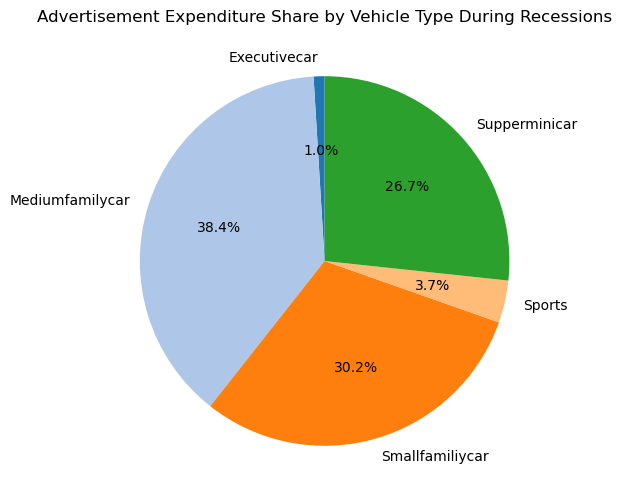

In [15]:
import matplotlib.pyplot as plt

# Filter the data for recession periods
Rdata = df[df['Recession'] == 1]

# Calculate the advertising expenditure by vehicle type during recessions
VTexpenditure = Rdata.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

# Create a pie chart for the share of each vehicle type in total expenditure during recessions
plt.figure(figsize=(8, 6))

labels = VTexpenditure.index
sizes = VTexpenditure.values
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=plt.cm.tab20.colors)

plt.title('Advertisement Expenditure Share by Vehicle Type During Recessions')

plt.show()


During recession the advertisements were mostly focued on low price range vehicle. A wise decision!

C:\Users\faffo\AppData\Local\Temp\ipykernel_41612\3022118631.py:9: UserWarning: 
The markers list has fewer values (1) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(


<Figure size 1200x600 with 0 Axes>

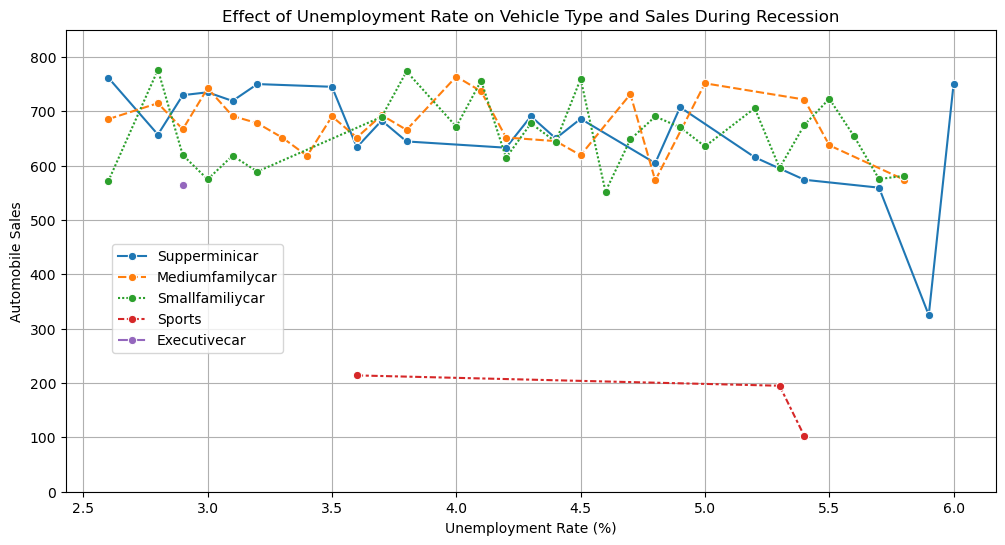

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter data for recession periods
df_rec = df[df['Recession'] == 1]

# Create line plot
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_rec,
    x='unemployment_rate',       # correct column name
    y='Automobile_Sales',
    hue='Vehicle_Type',
    style='Vehicle_Type',
    markers='o',
    err_style=None
)

# Customize plot
plt.ylim(0, 850)  # adjust based on your data
plt.title('Effect of Unemployment Rate on Vehicle Type and Sales During Recession')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Automobile Sales')
plt.legend(loc=(0.05, 0.3))
plt.grid(True)
plt.show()


During recession, buying pattern changed, the sales of low range vehicle like superminicar,smallfamilycar and Mediumminicar
